# Análise exploratória Telco Customer Churn
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Dataset com dados de uma empresa de telecomunicações que forneceu serviço de telefonia e internet para 7.043 clientes na Califórnia.

- Tamanho: 7.043 registros e 21 variáveis (colunas).
- Principais Atributos:
  - Dados Demográficos: Gênero, idade (idoso ou não), parceiros e dependentes.
  - Serviços Contratados: Linhas telefônicas, tipo de internet (DSL, Fibra ótica), segurança online, suporte técnico, streaming de TV e filmes
  - Informações Financeiras e Contratuais: Tempo de permanência (tenure), tipo de contrato (mensal, anual), método de pagamento, cobranças mensais (MonthlyCharges) e totais (TotalCharges).

**Importar bibliotecas e carregar dados**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

file_path = 'data/WA_Fn-UseC_-Telco-Customer-Churn_Clean.csv'
data = pd.read_csv(file_path)
pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


**Salvar alterações no csv (Perigoso...)**

In [ ]:
# data.to_csv(r"data\WA_Fn-UseC_-Telco-Customer-Churn_Clean.csv", index=False)

# Descrição dos dados

Informações de clientes de uma empresa de telecomunicações, contendo dados demográficos, assinaturas de serviços, detalhes da conta, informações de faturamento e uma marcação **(flag)** de rotatividade **(churn)**, que indica se o cliente cancelou o serviço. Ele ajuda a analisar o comportamento do cliente e a identificar os principais fatores que contribuem para a evasão de clientes **(churn)**.

- **customerID** – Identificador exclusivo atribuído a cada cliente.
- **gender** – Gênero do cliente (Male/Female).
- **SeniorCitizen** – Indica se o cliente é idoso (0 = Não, 1 = Sim).
- **Partner** – Se o cliente tem um parceiro/companheiro (Yes/No).
- **Dependents** – Se o cliente possui dependentes (Yes/No).
- **tenure** – Número de meses que o cliente percontrata/contratou a empresa.
- **PhoneService** – Indica se o cliente possui serviço de telefonia (Yes/No).
- **MultipleLines** – Múltiplas linhas telefônicas.
- **InternetService** – Tipo de serviço de internet (DSL/Fiber optic/No internet service).
- **OnlineSecurity** – Status do serviço de segurança online.
- **OnlineBackup** – Status do serviço de backup online.
- **DeviceProtection** – Status do plano de proteção de dispositivos.
- **TechSupport** – Status do serviço de suporte técnico.
- **StreamingTV** – Acesso ao serviço de streaming de TV.
- **StreamingMovies** – Acesso ao serviço de streaming de filmes.
- **Contract** – Tipo de contrato do cliente (Month-to-month/One year/Two year).
- **PaperlessBilling** – Indica se o cliente utiliza faturamento digital (Yes/No).
- **PaymentMethod** – Forma de pagamento do cliente.
- **MonthlyCharges** – Valor cobrado mensalmente do cliente.
- **TotalCharges** – Total de despesas acumuladas pelo cliente.
- **Churn** – Indica se o cliente descontinuou/cancelou o serviço (Yes/No).

# 1. Visualização dos dados

In [ ]:
# exibe a quantidade de linhas e colunas, junto de uma breve vizualisação dos dados
## data.head() - primeiras linhas | data.tail() - as últimas linhas

print(f"rows: {data.shape[0]} / columns {data.shape[1]}")
data.head()
#data.tail()

rows: 7043 / columns 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# exibe todas as colunas do dataset em string

data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [ ]:
# os tipos de dados que compoem o dataset

#data.dtypes
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
# exibe apenas as colunas numéricas, isolando em int e float

num_col = data.select_dtypes(include=['float64','int64'])
num_col

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [ ]:
# separa as colunas do dataset que são do tipo objeto/string

cat_col = data.select_dtypes(include=['object'])
cat_col.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [ ]:
# estatísticas das colunas numéricas (média, mediana, desvio padrão, min/max)

data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# vizualisação de valores nulos por coluna

#data.isnull()
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
# quantidade de valores preenchidos em cada coluna

data.count()

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
dtype: int64

In [ ]:
# distribuição de dados numericos e a frequencia de categorias

data.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2281.916928,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2265.270398,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,402.225000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


In [ ]:
# descritivas para dados do tipo string/objeto

data.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [ ]:
# lista os valores unicos de cada coluna

list_it =['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn']
for x in list_it:
  print(x)
  print(data[x].unique())
  print()

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract
<StringArray>
['Month-to-month', 'One year', 'T

In [ ]:
# exibir textos vazios (com espaço sendo contabilizado)

(data == " ").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
tc = data[data['TotalCharges'] == " "]
print(tc[['tenure', 'MonthlyCharges', 'TotalCharges']])

# clientes novos recebem 0 e TotalCharges marca como vazio

Empty DataFrame
Columns: [tenure, MonthlyCharges, TotalCharges]
Index: []


**Corrigindo TotalCharges**

In [ ]:
data.replace({" ": np.nan}, inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [ ]:
data['TotalCharges'].dtypes

dtype('float64')

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

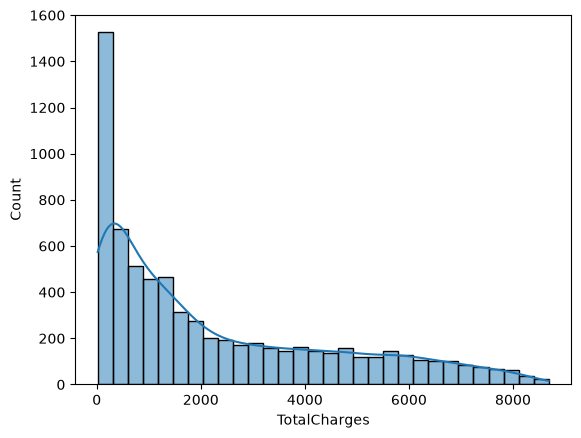

In [ ]:
# testando gráfico
sns.histplot(data['TotalCharges'], bins=30, kde=True)
plt.show()

In [ ]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

In [ ]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
for x in list_it:
  print(x)
  print(data[x].unique())
  print()

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract
<StringArray>
['Month-to-month', 'One year', 'T

# 2. Analises sobre os dados demográficos
### 1. Conhecendo o Perfil Demográfico da Nossa Base
Antes de cruzar os dados com os cancelamentos, buscamos entender quem são, de fato, os nossos clientes.

Nesta etapa, geramos um panorama geral da distribuição demográfica analisando quatro variáveis: gênero, se o cliente é idoso (`SeniorCitizen`), se tem parceiro(a) (`Partner`) e se tem dependentes (`Dependents`). Isso nos dá uma "foto" de como a nossa carteira está composta hoje e ajuda a evitar conclusões precipitadas mais para frente.

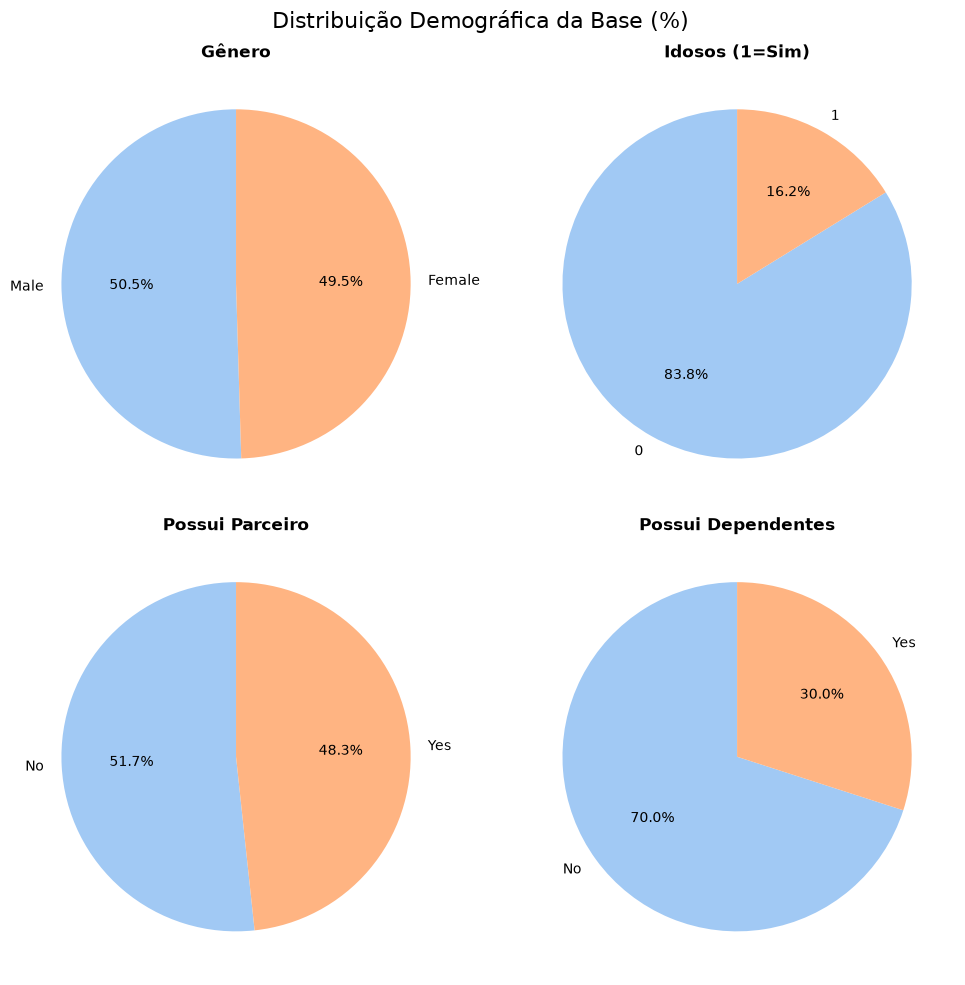

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
variaveis = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
titulos = ['Gênero', 'Idosos (1=Sim)', 'Possui Parceiro', 'Possui Dependentes']

for ax, var, titulo in zip(axes.flatten(), variaveis, titulos):
    contagem = data[var].value_counts()
    ax.pie(contagem, labels=contagem.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    ax.set_title(titulo, fontweight='bold')

plt.suptitle("Distribuição Demográfica da Base (%)", fontsize=16)
plt.tight_layout()
plt.show()

### 2. Diagnóstico de Evasão: Onde estamos perdendo clientes?
Agora buscamos entender como esses perfis demográficos se comportam em relação ao cancelamento de serviços (`Churn`).

Aqui, cruzamos as variáveis que acabamos de ver diretamente com a coluna alvo. A ideia é bater o olho nos gráficos e identificar se existe algum grupo específico vazando mais do que deveria. Por exemplo: será que o público idoso tem uma taxa de retenção menor? O gênero influencia em algo?

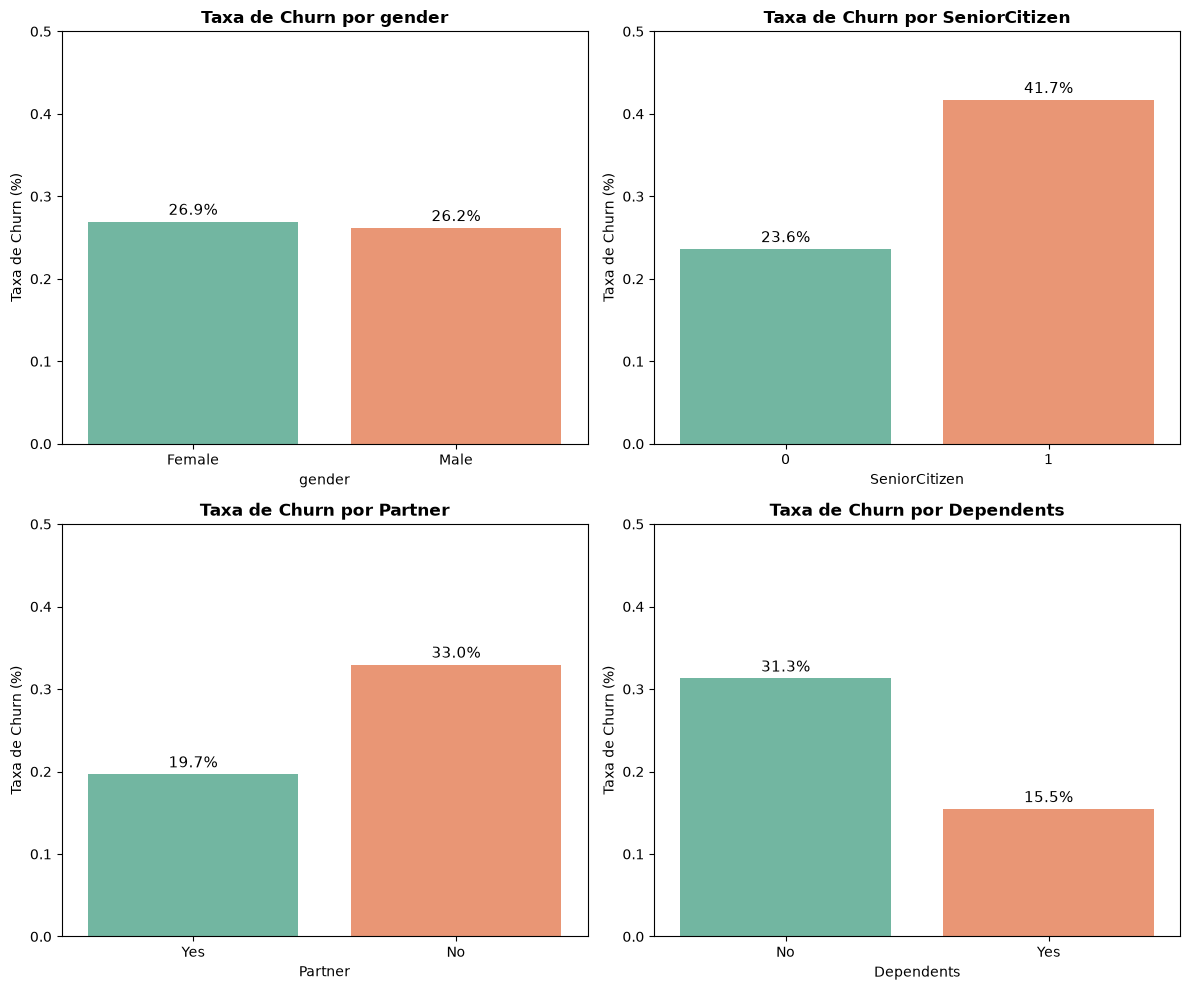

In [ ]:
if 'Churn_Rate' not in data.columns:
    data['Churn_Rate'] = data['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
variaveis = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for ax, var in zip(axes.flatten(), variaveis):
    sns.barplot(data=data, x=var, y='Churn_Rate', ax=ax, palette='Set2', errorbar=None)

    ax.set_title(f'Taxa de Churn por {var}', fontweight='bold')
    ax.set_ylabel('Taxa de Churn (%)')
    ax.set_ylim(0, 0.5)

    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

### 3. Segmentação: Testando a Hipótese da "Estrutura Familiar"
Analisar as colunas de forma isolada é bom, mas combinar dados costuma trazer insights mais profundos.

Fizemos uma pequena engenharia de recursos (Feature Engineering) e criamos uma nova variável chamada `EstruturaFamiliar`. Se o cliente tiver um parceiro ou dependentes, classificamos como "Com Família"; caso contrário, será classificado como "Sozinho". O objetivo é testar a hipótese de que clientes com mais raízes/laços familiares tendem a ser mais estáveis e cancelar menos.

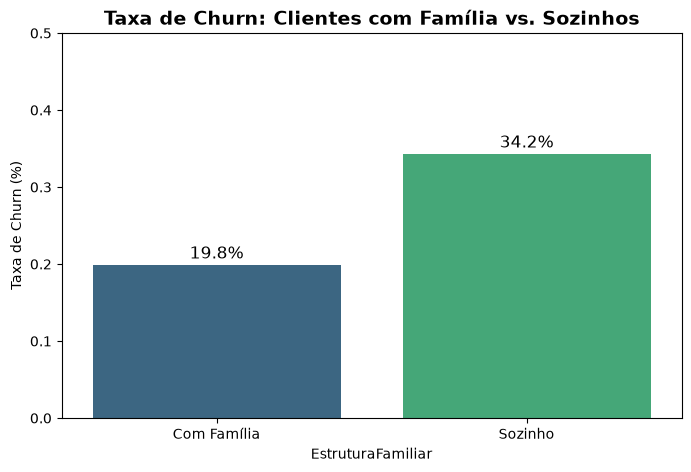

In [ ]:
data['EstruturaFamiliar'] = np.where((data['Partner'] == 'Yes') | (data['Dependents'] == 'Yes'), 'Com Família', 'Sozinho')

if 'Churn_Rate' not in data.columns:
    data['Churn_Rate'] = data['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=data, x='EstruturaFamiliar', y='Churn_Rate', palette='viridis', errorbar=None)

plt.title("Taxa de Churn: Clientes com Família vs. Sozinhos", fontsize=14, fontweight='bold')
plt.ylabel("Taxa de Churn (%)")
plt.ylim(0, 0.5)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### A Onda de Cancelamentos: Quando perdemos o cliente?

Diferente de ver apenas a média de tempo, o gráfico de densidade nos mostra o "pulso" dos cancelamentos, revelando exatamente onde está o pico de perdas.

* **O que o gráfico mostra:** A curva de clientes **sem dependentes** tem um pico muito acentuado e concentrado nos primeiros meses de contrato. Depois desse susto inicial, a curva cai e se estabiliza. Já os clientes com dependentes têm uma curva de saída muito mais "espalhada" e suave ao longo dos meses.
* **O que isso significa na prática:** O cliente solteiro/sem filhos não apenas cancela mais, ele cancela **muito rápido**. A janela crítica de retenção para esse grupo é nos 2 ou 3 primeiros meses. Passou dessa fase, o risco despenca. Ações de marketing (como descontos progressivos ou bônus nos 3 primeiros meses) devem focar cirurgicamente aqui.

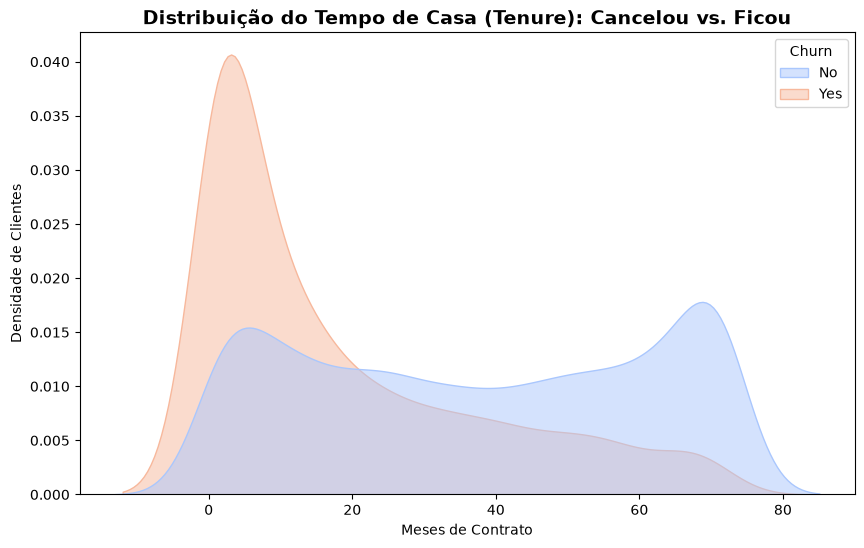

In [ ]:
plt.figure(figsize=(10, 6))

# Plotando as curvas de densidade
sns.kdeplot(data=data, x='tenure', hue='Churn', common_norm=False, fill=True, palette='coolwarm', alpha=0.5)

plt.title("Distribuição do Tempo de Casa (Tenure): Cancelou vs. Ficou", fontsize=14, fontweight='bold')
plt.xlabel("Meses de Contrato")
plt.ylabel("Densidade de Clientes")
plt.show()

### 5. Tirando a Prova Real: Validação Estatística
Visualizações são ótimas para levantar suspeitas, mas precisamos ter certeza de que o que estamos vendo não é apenas uma variação aleatória da nossa amostra.

Para fechar essa etapa demográfica, vamos rodar um **Teste de Qui-Quadrado**. Ele vai validar matematicamente se existe uma relação estatisticamente significativa entre a variável `SeniorCitizen` (ser idoso) e o `Churn`, ou se qualquer diferença nas taxas foi apenas obra do acaso.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(tabela_contingencia, annot=True, fmt='d', cmap='Blues',
            linewidths=1, linecolor='white', cbar=False)

plt.title("Mapa de Calor: Idosos vs. Churn", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cancelou? (Churn)", fontweight='bold')
plt.ylabel("É Idoso? (SeniorCitizen)", fontweight='bold')
plt.show()

print(f"Estatística Qui-Quadrado (calculada): {chi2:.4f}")
if chi2 > valor_critico:
    print("Resultado: Há uma relação estatisticamente significativa entre ser idoso e o Churn.")
else:
    print("Resultado: Não há evidências suficientes para dizer que ser idoso afeta o Churn (pode ser acaso).")

NameError: name 'tabela_contingencia' is not defined

<Figure size 700x500 with 0 Axes>

### Diagnóstico: O peso do perfil demográfico no Churn

Traduzindo os gráficos em insights de negócio, podemos notar padrões muito claros sobre quem são os clientes que mais cancelam:

**1. Gênero (Gender)**
* **O que vemos:** As taxas de retenção e cancelamento são praticamente idênticas para homens e mulheres.
* **Insight prático:** Gênero não é um fator de decisão para o nosso produto. Não precisamos gastar tempo ou orçamento criando campanhas de retenção segmentadas por sexo.

**2. Idosos (SeniorCitizen)**
* **O que vemos:** Os idosos representam uma fatia pequena da base, mas a proporção de cancelamento dentro desse grupo é visivelmente maior se comparada aos clientes mais jovens.
* **Insight prático:** Temos um ponto de atenção. Esse alto nível de evasão levanta algumas hipóteses para investigar: os planos estão caros para aposentados? A usabilidade dos serviços ou o suporte técnico não estão amigáveis para eles?

**3. Parceiros (Partner)**
* **O que vemos:** Clientes solteiros ou que moram sozinhos apresentam um volume de cancelamento significativamente superior.
* **Insight prático:** A presença de um parceiro traz estabilidade. É possível que os custos da casa sendo divididos façam com que o serviço de internet/telefone pese menos no bolso e se torne mais indispensável para o casal.

**4. Dependentes (Dependents)**
* **O que vemos:** O cenário mais crítico de evasão está entre os clientes sem dependentes. Em contrapartida, aqueles com família/filhos apresentam uma lealdade muito maior à empresa.
* **Insight prático:** Clientes independentes são altamente voláteis e representam nosso maior risco. Se o time de marketing for desenhar estratégias agressivas de fidelização (como descontos nos primeiros meses ou upgrades de velocidade gratuitos), o foco deve ser tentar "segurar" esse público sem dependentes.

# 3. Análises sobre os dados contratuais e financeiros

### 1. Preparando as variáveis para a análise

Nesta etapa, vamos focar nas informações contratuais e financeiras dos clientes para entender se elas possuem alguma relação com o cancelamento.

Para isso, selecionamos principalmente o tipo de contrato (`Contract`), o valor da mensalidade (`MonthlyCharges`), o valor total pago (`TotalCharges`) e o `Churn`.

Antes de começar os cruzamentos, verificamos os tipos dessas colunas e se existem valores nulos.

In [ ]:
data[['Contract', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Rate']].info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Contract        7043 non-null   str    
 1   MonthlyCharges  7043 non-null   float64
 2   TotalCharges    7043 non-null   float64
 3   Churn           7043 non-null   str    
 4   Churn_Rate      7043 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 275.2 KB


### 2. Tipo de contrato e cancelamento

Primeiro, queremos entender se o tempo de compromisso do contrato possui qualquer tipo de relação com o cancelamento.

Para isso, agrupamos os clientes por tipo de contrato: mensal (`Month-to-month`), anual (`One year`) e de dois anos (`Two year`).

Calculamos para cada grupo a quantidade de clientes, número de cancelamentos e a taxa de churn. Assim, conseguimos fazer a comparação os contratos considerando a proporção de clientes que cancelaram mesmo e naõ só o número total de cancelamentos.

In [ ]:
contrato_churn = (
    data.groupby('Contract')
    .agg(
        Clientes=('Churn', 'size'),
        Cancelamentos=('Churn_Rate', 'sum'),
        Taxa_Churn=('Churn_Rate', 'mean')
    )
    .sort_values('Taxa_Churn', ascending=False)
)

contrato_churn['Taxa_Churn'] = (
    contrato_churn['Taxa_Churn'] * 100
).round(2)

contrato_churn

,Clientes,Cancelamentos,Taxa_Churn
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


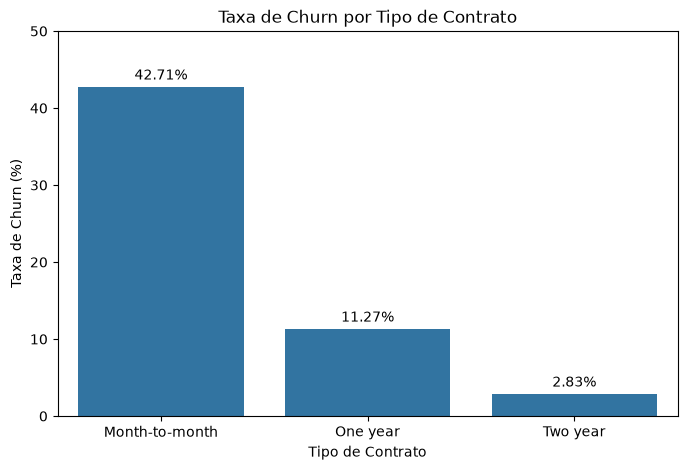

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contrato_churn.index,
    y=contrato_churn['Taxa_Churn']
)

plt.title('Taxa de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Taxa de Churn (%)')

for i, valor in enumerate(contrato_churn['Taxa_Churn']):
    plt.text(i, valor + 1, f'{valor:.2f}%', ha='center')

plt.ylim(0, 50)

plt.show()

O resultado mostra uma grande diferença entre os tipos de contratos. Nos contratos mensais, a taxa de churn chegou a **42,71%**, enquanto nos contratos de um ano foi de **11,27%** e nos contratos de dois anos apenas **2,83%**.

Esse foi o primeiro sinal de que clientes com contratos mais curos estão mais presentes entre os cancelamentos. Porém, apenas essa comparação ainda não explica o motivo dessa diferença.

### 3. Comparando os valores pagos por quem cancelou e quem permaneceu

Depois de observar a diferença entre os contratos, passamos para os valores pagos pelos clientes.
Comparamos a mensalidade média e mediana (`MonthlyCharges`), o gasto total (`TotalCharges`) e o tempo médio de permanência (`tenure`) entre os clientes que cancelaram e os que continuaram na empresa.

O objetivo aqui é verificar se quem cancela costuma pagar valores diferentes e também entender de que maneira o tempo como cliente interfere de alguma forma no gasto acumulado.

In [ ]:
resumo_financeiro = (
    data.groupby('Churn')
    .agg(
        Mensalidade_Media=('MonthlyCharges', 'mean'),
        Mensalidade_Mediana=('MonthlyCharges', 'median'),
        Gasto_Total_Medio=('TotalCharges', 'mean'),
        Gasto_Total_Mediano=('TotalCharges', 'median'),
        Tempo_Medio=('tenure', 'mean')
    )
    .round(2)
)

resumo_financeiro

,Mensalidade_Media,Mensalidade_Mediana,Gasto_Total_Medio,Gasto_Total_Mediano,Tempo_Medio
Churn,,,,,
No,61.27,64.43,2552.88,1679.52,37.57
Yes,74.44,79.65,1531.80,703.55,17.98


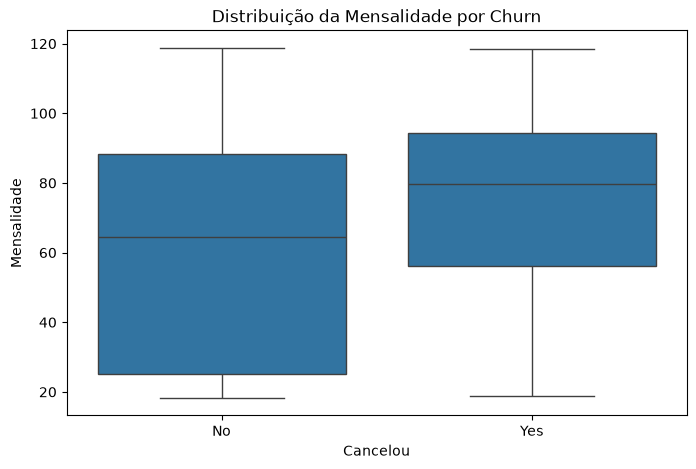

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Distribuição da Mensalidade por Churn')
plt.xlabel('Cancelou')
plt.ylabel('Mensalidade')

plt.show()

Os clientes que cancelaram apresentaram uma mensalidade média de **74,44**, enquanto entre os clientes que permaneceram a média foi de **61,27**. A diferença também aparece na mediana: **79,65** entre quem cancelou e **64,43** entre quem permaneceu.

Por outro lado, o gasto total dos clientes que cancelaram é menor. Isso faz sentido quando observamos o tempo de permanência: quem cancelou ficou, em média, **17,98 meses** na empresa, enquanto quem permaneceu chegou a **37,57 meses**.

Portanto, os clientes que cancelaram tendem a pagar mais por mês, mas permanecem menos tempo, acumulando um valor total menor.

### 4. Cruzando contrato e valor da mensalidade

Até aqui, vimos duas coisas separadamente: contratos mensais possuem maior churn e clientes que cancelam possuem mensalidades mais altas.

Por isso, decidimos cruzar essas duas informações para verificar se existe algum grupo onde o cancelamento fica ainda mais concentrado.

Para facilitar a comparação, dividimos `MonthlyCharges` em três faixas:

- até 35;
- de 35 a 70;
- acima de 70.

Depois calculamos a taxa de churn para cada combinação entre a faixa de mensalidade e tipo de contrato.

In [ ]:
data['Faixa_Mensalidade'] = pd.cut(
    data['MonthlyCharges'],
    bins=[0, 35, 70, float('inf')],
    labels=['Até 35', '35 a 70', 'Acima de 70']
)

contrato_mensalidade = (
    data.groupby(
        ['Contract', 'Faixa_Mensalidade'],
        observed=True
    )['Churn_Rate']
    .mean()
    .unstack()
    * 100
).round(2)

contrato_mensalidade

Faixa_Mensalidade,Até 35,35 a 70,Acima de 70
Contract,,,
Month-to-month,24.29,35.33,52.69
One year,3.12,7.82,17.43
Two year,0.78,2.11,4.81


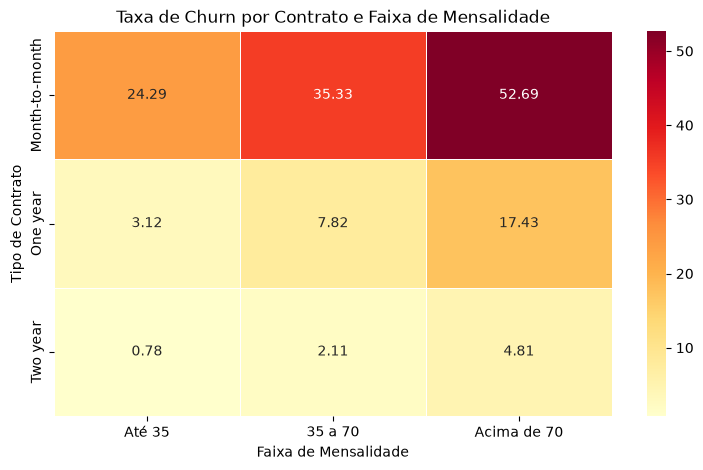

In [ ]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    contrato_mensalidade,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Taxa de Churn por Contrato e Faixa de Mensalidade')
plt.xlabel('Faixa de Mensalidade')
plt.ylabel('Tipo de Contrato')

plt.show()

O cruzamento deixou o padrão mais evidente. Entre os clientes com contrato mensal e mensalidade acima de 70, a taxa de churn chegou a **52,69%**, sendo o maior valor encontrado nessa comparação.

Na mesma faixa de mensalidade, clientes com contrato anual tiveram churn de **17,43%**, enquanto nos contratos de dois anos a taxa foi de apenas **4,81%**.

Isso mostra que uma mensalidade alta, sozinha, não parece explicar o comportamento. O tipo de contrato também está fortemente relacionado às diferenças encontradas.

### Diagnóstico: O peso do contrato e da mensalidade no Churn

Depois das comparações, dois fatores chamaram bastante atenção: o tipo de contrato e o valor da mensalidade.

**1. Tipo de contrato**
* **O que vemos:** Clientes com contrato mês a mês apresentam churn de 42,71%, muito acima dos contratos de um ano (11,27%) e dois anos (2,83%).
* **Insight:** O churn está muito mais concentrado entre clientes que não possuem um contrato de longo prazo.

**2. Valor da mensalidade**
* **O que vemos:** Quem cancelou possui mensalidade média maior (74,44) do que quem permaneceu (61,27).
* **Insight:** Valores mensais mais altos aparecem com maior frequência entre os clientes que cancelam.

**3. Contrato + mensalidade**
* **O que vemos:** O grupo mais crítico foi formado por clientes com contrato mês a mês e mensalidade acima de 70, com churn de 52,69%.
* **Insight:** A combinação entre mensalidade mais alta e contrato de curto prazo parece caracterizar um grupo com maior ocorrência de cancelamentos.

### Hipótese

Clientes com mensalidades mais altas e contratos mês a mês podem ter maior facilidade ou incentivo para trocar de empresa, já que não possuem um vínculo contratual de longo prazo.

Os dados mostram uma associação entre essas características e o churn, mas não permitem afirmar que elas sejam, sozinhas, a causa do cancelamento.